In [24]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [25]:
train_df = pd.read_csv("/kaggle/input/competitions/nlp-getting-started/train.csv")
train_df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## Data Processing

First I will try to see the information about the dataset

In [26]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


From the information, it seems that there are only 2 columns that are valueable for the training. Thus I will drop other columns.

In [27]:
train_df.drop(columns=["id", "keyword", "location"], inplace=True)

Since I have cleaned the data, now it's time to split it for training

In [28]:
X = train_df["text"]
y = train_df["target"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

Next I will see the word count of the each tweet, this will be useful for the tokenization

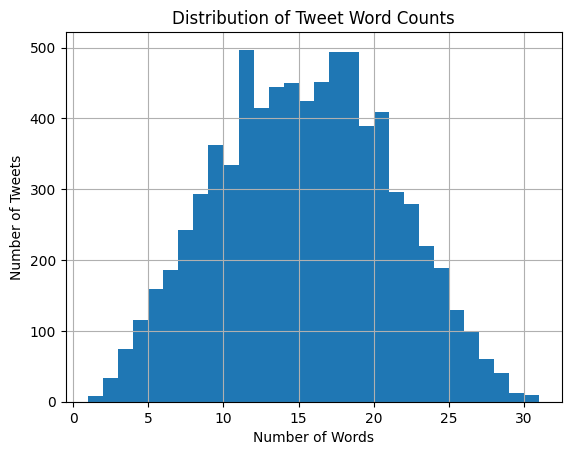

In [29]:
train_df['text'].apply(lambda x: len(str(x).split())).hist(bins=30)
plt.title('Distribution of Tweet Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Number of Tweets')
plt.show()

From the graph, the max number of words is about 32. So next I will tokenize the word.

In [30]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Initialize the "Dictionary" (Limit to the top 10,000 words)
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train) # Learn words from training data only!

# 2. Convert words to numbers
train_sequences = tokenizer.texts_to_sequences(X_train)
val_sequences = tokenizer.texts_to_sequences(X_val)

# 3. Make every tweet exactly 35 numbers long
# We pad with zeros at the end ('post')
max_length = 35
X_train_ready = pad_sequences(train_sequences, maxlen=max_length, padding='pre', truncating='post')
X_val_ready = pad_sequences(val_sequences, maxlen=max_length, padding='pre', truncating='post')

## Baseline Model
This will be the model train with CNN

In [31]:
from tensorflow.keras import layers

model = tf.keras.Sequential([
    layers.Embedding(10000, 16),
    layers.SpatialDropout1D(0.2), # Prevent word-feature memorization
    layers.Bidirectional(layers.LSTM(32, dropout=0.2, recurrent_dropout=0.2)),
    layers.Dense(24, activation='relu'),
    layers.Dropout(0.4), # Final shield against overfitting
    layers.Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [32]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(X_train_ready, y_train, epochs=10, validation_data=(X_val_ready, y_val), callbacks=[early_stop])

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.5417 - loss: 0.6851 - val_accuracy: 0.7124 - val_loss: 0.5866
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.7755 - loss: 0.5083 - val_accuracy: 0.7938 - val_loss: 0.4576
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.8662 - loss: 0.3514 - val_accuracy: 0.8030 - val_loss: 0.4657
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.9009 - loss: 0.2893 - val_accuracy: 0.7886 - val_loss: 0.4957


In [47]:
from sklearn.metrics import f1_score, classification_report

# 1. Get probabilities
y_pred_probs = model.predict(X_val_ready)

# 2. Convert probabilities to binary (0 or 1) using a threshold
y_pred = (y_pred_probs > 0.3).astype("int32")

# 3. Calculate F1
f1 = f1_score(y_val, y_pred)
print(f"F1 Score: {f1:.4f}")
print(classification_report(y_val, y_pred, target_names=['Not Disaster', 'Disaster']))

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
F1 Score: 0.7569
              precision    recall  f1-score   support

Not Disaster       0.80      0.87      0.83       869
    Disaster       0.81      0.71      0.76       654

    accuracy                           0.80      1523
   macro avg       0.80      0.79      0.80      1523
weighted avg       0.80      0.80      0.80      1523



In [50]:
# Find indices where it was a Disaster (1) but we predicted Not Disaster (0)
false_negatives = (y_val == 1) & (y_pred.flatten() == 0)

# Show the first 5 missed disasters
missed_tweets = X_val[false_negatives].iloc[:5]
for tweet in missed_tweets:
    print(f"MISSING DISASTER: {tweet}\n")

MISSING DISASTER: ok peace I hope I fall off a cliff along with my dignity

MISSING DISASTER: TWIA board approves 5 percent rate hike: The Texas Windstorm Insurance Association (TWIA) Board of Directors v... http://t.co/TWPl0NL8cx

MISSING DISASTER: How long O Lord (Study 3)
 The sixth seal opens the events of Revelation 12. The political upheaval in the Roman... http://t.co/GW0CXoOJyV

MISSING DISASTER: DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q

MISSING DISASTER: Thunder pounds north goes black
a deep bruise on the sky's chest
wind cries its pain.  
A summer storm has a tough life
short violent.



## Improve the model
Now since I already have the baseline model, I will try to improve it. From the missing disaster, I think that the vocabulary of the model is not enough. So I will use the **GloVe** a pre-trained dictionary.

In [56]:
import numpy as np

# Path to GloVe in Kaggle
glove_path = '/kaggle/input/datasets/yesornope/glove6b/glove.6B.100d.txt'
embeddings_index = {}
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f'Found {len(embeddings_index)} word vectors.')

Found 400001 word vectors.


In [57]:
embedding_dim = 100 # Match the GloVe file dimension
word_index = tokenizer.word_index
num_words = min(10000, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, embedding_dim))

for word, i in word_index.items():
    if i < 10000:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            # Words not found in embedding index will be all-zeros.
            embedding_matrix[i] = embedding_vector

In [90]:
from tensorflow.keras import layers

model_v2 = tf.keras.Sequential([
    layers.Embedding(num_words, 
                     embedding_dim, 
                     embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
                     trainable=False), # Freeze the "dictionary" first
    layers.SpatialDropout1D(0.2),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.GlobalMaxPool1D(), # Picks out the most "intense" signals from the LSTM
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])
model_v2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [91]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model_v2.fit(X_train_ready, y_train, epochs=10, validation_data=(X_val_ready, y_val), callbacks=[early_stop])

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7036 - loss: 0.5736 - val_accuracy: 0.8024 - val_loss: 0.4496
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7879 - loss: 0.4752 - val_accuracy: 0.7905 - val_loss: 0.4397
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7976 - loss: 0.4468 - val_accuracy: 0.8024 - val_loss: 0.4330
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8122 - loss: 0.4309 - val_accuracy: 0.8043 - val_loss: 0.4287
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8095 - loss: 0.4141 - val_accuracy: 0.8063 - val_loss: 0.4361
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8206 - loss: 0.4025 - val_accuracy: 0.8063 - val_loss: 0.4279
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8299 - loss: 0.3981 - val_accuracy: 0.8102 - val_loss: 0.4235
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8393 - loss: 0.3785 - val_accu

In [92]:
model_v2.layers[0].trainable = True
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history_finetune = model_v2.fit(
    X_train_ready, 
    y_train,
    epochs=5, 
    validation_data=(X_val_ready, y_val),
    callbacks=[early_stop] # Keep the safety switch on!
)

Epoch 1/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8476 - loss: 0.3669 - val_accuracy: 0.8116 - val_loss: 0.4225
Epoch 2/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.8436 - loss: 0.3626 - val_accuracy: 0.8116 - val_loss: 0.4223
Epoch 3/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8534 - loss: 0.3620 - val_accuracy: 0.8129 - val_loss: 0.4221
Epoch 4/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8471 - loss: 0.3645 - val_accuracy: 0.8129 - val_loss: 0.4222
Epoch 5/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8497 - loss: 0.3534 - val_accuracy: 0.8129 - val_loss: 0.4223


In [93]:
y_pred_probs = model_v2.predict(X_val_ready)

y_pred = (y_pred_probs > 0.3).astype("int32")

# 3. Calculate F1
f1 = f1_score(y_val, y_pred)
print(f"F1 Score: {f1:.4f}")
print(classification_report(y_val, y_pred, target_names=['Not Disaster', 'Disaster']))

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
F1 Score: 0.7760
              precision    recall  f1-score   support

Not Disaster       0.85      0.79      0.82       869
    Disaster       0.74      0.81      0.78       654

    accuracy                           0.80      1523
   macro avg       0.80      0.80      0.80      1523
weighted avg       0.80      0.80      0.80      1523



## Submit the result

In [54]:
test_df = pd.read_csv("/kaggle/input/competitions/nlp-getting-started/test.csv")

X_test= test_df["text"]
test_sequences = tokenizer.texts_to_sequences(X_test)
X_test_ready = pad_sequences(test_sequences, maxlen=max_length, padding='pre', truncating='post')
prediction_probs = model_v2.predict(X_test_ready)
prediction = (prediction_probs > 0.3).astype("int32").flatten()

submission = pd.DataFrame({
    "id": test_df["id"],
    "target": prediction
})
submission.to_csv("submission.csv", index=False)

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
